# Coelogyne ArcFace — Stratified 5-Fold Cross-Validation

Notebook ini mengganti single 80/20 split menjadi **StratifiedKFold (k=5)** untuk:
- **MobileNetV2 + ArcFace**
- **EfficientNetV2S + ArcFace**

Output utama per model:
- akurasi per fold
- agregat mean ± std dan 95% CI
- precision/recall/F1 per kelas (mean ± std)
- confusion matrix agregat (sum + normalized)

> **Known constraint (wajib dibaca):**
> All current images per class come from a single photography session (verified via EXIF DateTimeOriginal — full timestamp spans are 5–20 min per class, all on 2026-04-22, one specimen each). This means any cross-validation on this dataset — including this one — measures same-specimen recognition, not species-level generalization to new plants.


In [8]:
import os
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks, optimizers, regularizers
from tensorflow.keras.applications import MobileNetV2, EfficientNetV2S

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix
from IPython.display import display

print('TensorFlow:', tf.__version__)
print('Keras:', keras.__version__)
print('GPU available:', len(tf.config.list_physical_devices('GPU')) > 0)


TensorFlow: 2.18.1
Keras: 3.12.2
GPU available: True


In [9]:
# =========================
# Configuration
# =========================
DATASET_DIR = './data'
CLASS_NAMES = ['Asperata', 'Dayana', 'Pandurata', 'Rumphii', 'Swaniana']
NUM_CLASSES = len(CLASS_NAMES)

SEED = 42
NUM_FOLDS = 5

IMG_SIZE_ARC = (384, 384)
BATCH_SIZE_ARC = 4
EPOCHS_HEAD_ARC = 15
EPOCHS_FINETUNE_ARC = 20
LEARNING_RATE_ARC = 1e-3
FINETUNE_LR_ARC = 1e-5
ARCFACE_EMBED_DIM = 256
ARCFACE_MARGIN = 0.35
ARCFACE_SCALE = 30.0

AUTOTUNE = tf.data.AUTOTUNE
SAVE_DIR = './saved_models/kfold_arcface'
os.makedirs(SAVE_DIR, exist_ok=True)

SINGLE_SESSION_DISCLAIMER = (
    'All current images per class come from a single photography session '
    '(verified via EXIF DateTimeOriginal — full timestamp spans are 5–20 min per class, '
    'all on 2026-04-22, one specimen each). This means any cross-validation on this dataset '
    '— including this one — measures same-specimen recognition, not species-level '
    'generalization to new plants.'
)

np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

print('Config loaded.')
print('NUM_FOLDS:', NUM_FOLDS)
print('IMG_SIZE_ARC:', IMG_SIZE_ARC)
print('BATCH_SIZE_ARC:', BATCH_SIZE_ARC)


Config loaded.
NUM_FOLDS: 5
IMG_SIZE_ARC: (384, 384)
BATCH_SIZE_ARC: 4


In [10]:
# =========================
# Explicit file list pipeline
# =========================
def enumerate_image_paths_and_labels(dataset_dir, class_names):
    root = Path(dataset_dir)
    exts = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}

    file_paths = []
    labels = []

    for class_idx, class_name in enumerate(class_names):
        class_dir = root / class_name
        if not class_dir.exists():
            raise FileNotFoundError(f'Class directory not found: {class_dir}')

        class_files = sorted([
            p for p in class_dir.rglob('*')
            if p.is_file() and p.suffix.lower() in exts
        ])

        file_paths.extend([str(p) for p in class_files])
        labels.extend([class_idx] * len(class_files))

    file_paths = np.asarray(file_paths)
    labels = np.asarray(labels, dtype=np.int32)
    return file_paths, labels


all_file_paths, all_labels = enumerate_image_paths_and_labels(DATASET_DIR, CLASS_NAMES)

print(f'Total images found: {len(all_file_paths)}')
for i, class_name in enumerate(CLASS_NAMES):
    print(f'  {class_name:10s}: {(all_labels == i).sum()}')

if len(all_file_paths) != 393:
    print('WARNING: expected 393 images based on work order, but found:', len(all_file_paths))

skf = StratifiedKFold(n_splits=NUM_FOLDS, shuffle=True, random_state=SEED)
fold_indices = list(skf.split(all_file_paths, all_labels))

print('')
print('Stratified folds prepared:', len(fold_indices))
for fold_id, (tr_idx, va_idx) in enumerate(fold_indices, start=1):
    tr_counts = np.bincount(all_labels[tr_idx], minlength=NUM_CLASSES)
    va_counts = np.bincount(all_labels[va_idx], minlength=NUM_CLASSES)
    print(f'Fold {fold_id}: train={len(tr_idx)} val={len(va_idx)} | train_counts={tr_counts.tolist()} val_counts={va_counts.tolist()}')


Total images found: 393
  Asperata  : 62
  Dayana    : 104
  Pandurata : 67
  Rumphii   : 107
  Swaniana  : 53

Stratified folds prepared: 5
Fold 1: train=314 val=79 | train_counts=[49, 83, 54, 86, 42] val_counts=[13, 21, 13, 21, 11]
Fold 2: train=314 val=79 | train_counts=[49, 84, 53, 86, 42] val_counts=[13, 20, 14, 21, 11]
Fold 3: train=314 val=79 | train_counts=[50, 83, 53, 86, 42] val_counts=[12, 21, 14, 21, 11]
Fold 4: train=315 val=78 | train_counts=[50, 83, 54, 85, 43] val_counts=[12, 21, 13, 22, 10]
Fold 5: train=315 val=78 | train_counts=[50, 83, 54, 85, 43] val_counts=[12, 21, 13, 22, 10]


In [11]:
# =========================
# tf.data pipeline (train/val)
# Augmentation aligned with prior ArcFace ImageDataGenerator config:
# rotation=30, shift=0.15, shear=0.1, zoom=0.2, hflip=True, brightness=[0.8,1.2]
# =========================
augment_layers = keras.Sequential([
    layers.RandomRotation(30.0 / 360.0, fill_mode='nearest', seed=SEED),
    layers.RandomTranslation(0.15, 0.15, fill_mode='nearest', seed=SEED),
    layers.RandomZoom(0.2, 0.2, fill_mode='nearest', seed=SEED),
    layers.RandomFlip('horizontal', seed=SEED),
], name='arc_train_augment')


def random_shear(image, max_shear=0.1):
    shear = tf.random.uniform([], -max_shear, max_shear, dtype=tf.float32)
    transform = tf.convert_to_tensor([1.0, shear, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0], dtype=tf.float32)

    image4 = tf.expand_dims(image, axis=0)
    out_hw = tf.shape(image)[0:2]
    sheared = tf.raw_ops.ImageProjectiveTransformV3(
        images=image4,
        transforms=tf.expand_dims(transform, axis=0),
        output_shape=out_hw,
        fill_value=0.0,
        interpolation='BILINEAR',
        fill_mode='REFLECT'
    )
    return tf.squeeze(sheared, axis=0)


def decode_and_resize(path, label):
    image = tf.io.read_file(path)
    image = tf.io.decode_image(image, channels=3, expand_animations=False)
    image = tf.image.resize(image, IMG_SIZE_ARC, method='bilinear')
    image = tf.cast(image, tf.float32) / 255.0
    y = tf.one_hot(label, depth=NUM_CLASSES)
    return image, y


def augment_train(image, label):
    image = augment_layers(image, training=True)
    image = random_shear(image, max_shear=0.1)
    image = tf.image.random_brightness(image, max_delta=0.2)
    image = tf.clip_by_value(image, 0.0, 1.0)
    return image, label


def build_fold_dataset(file_paths, labels, training):
    ds = tf.data.Dataset.from_tensor_slices((file_paths, labels))

    if training:
        ds = ds.shuffle(buffer_size=len(file_paths), seed=SEED, reshuffle_each_iteration=True)

    ds = ds.map(decode_and_resize, num_parallel_calls=AUTOTUNE)

    if training:
        ds = ds.map(augment_train, num_parallel_calls=AUTOTUNE)

    ds = ds.batch(BATCH_SIZE_ARC)
    ds = ds.prefetch(AUTOTUNE)
    return ds


In [12]:
# =========================
# ArcFace model components (keep fixed test_step/_flatten_logs)
# =========================
@keras.utils.register_keras_serializable(package='coelogyne')
class ArcMarginProduct(layers.Layer):
    def __init__(self, num_classes, scale=30.0, margin=0.35, **kwargs):
        super().__init__(**kwargs)
        self.num_classes = num_classes
        self.scale = scale
        self.margin = margin

    def build(self, input_shape):
        feat_dim = int(input_shape[-1])
        self.W = self.add_weight(
            name='arcface_W',
            shape=(feat_dim, self.num_classes),
            initializer='glorot_uniform',
            trainable=True
        )
        super().build(input_shape)

    def call(self, embeddings, labels=None, training=False):
        x = tf.nn.l2_normalize(embeddings, axis=1)
        w = tf.nn.l2_normalize(self.W, axis=0)
        cos_theta = tf.matmul(x, w)
        cos_theta = tf.clip_by_value(cos_theta, -1.0 + 1e-7, 1.0 - 1e-7)

        if (labels is None) or (not training):
            return cos_theta * self.scale

        theta = tf.acos(cos_theta)
        target_logits = tf.cos(theta + self.margin)
        one_hot = tf.one_hot(labels, depth=self.num_classes)
        logits = one_hot * target_logits + (1.0 - one_hot) * cos_theta
        return logits * self.scale
    
    def get_config(self):
        config = super().get_config()
        config.update({
            'num_classes': self.num_classes,
            'scale': self.scale,
            'margin': self.margin,
        })
        return config


@keras.utils.register_keras_serializable(package='coelogyne')
class ArcFaceClassifier(keras.Model):
    def __init__(self, feature_model, arc_head, **kwargs):
        super().__init__(**kwargs)
        self.feature_model = feature_model
        self.arc_head = arc_head

    def call(self, inputs, training=False):
        emb = self.feature_model(inputs, training=training)
        logits = self.arc_head(emb, labels=None, training=False)
        return tf.nn.softmax(logits)

    def train_step(self, data):
        x, y = data
        labels = tf.argmax(y, axis=1)

        with tf.GradientTape() as tape:
            emb = self.feature_model(x, training=True)
            logits = self.arc_head(emb, labels=labels, training=True)
            loss = self.compute_loss(x=x, y=y, y_pred=logits, sample_weight=None)

        vars_trainable = self.feature_model.trainable_variables + self.arc_head.trainable_variables
        grads = tape.gradient(loss, vars_trainable)
        self.optimizer.apply_gradients(zip(grads, vars_trainable))

        for metric in self.metrics:
            if metric.name == 'loss':
                metric.update_state(loss)
            else:
                metric.update_state(y, logits)
        return self._flatten_logs()

    def test_step(self, data):
        x, y = data
        emb = self.feature_model(x, training=False)
        logits = self.arc_head(emb, labels=None, training=False)
        loss = self.compute_loss(x=x, y=y, y_pred=logits, sample_weight=None)

        for metric in self.metrics:
            if metric.name == 'loss':
                metric.update_state(loss)
            else:
                metric.update_state(y, logits)
        return self._flatten_logs()

    def _flatten_logs(self):
        logs = {}
        for m in self.metrics:
            result = m.result()
            if isinstance(result, dict):
                logs.update(result)
            else:
                logs[m.name] = result
        return logs
    
    def get_config(self):
        config = super().get_config()

        if hasattr(keras, 'saving'):
            serialize_obj = keras.saving.serialize_keras_object
        else:
            serialize_obj = keras.utils.serialize_keras_object

        config.update({
            'feature_model': serialize_obj(self.feature_model),
            'arc_head': serialize_obj(self.arc_head),
        })
        return config


def build_mobilenet_feature_model(img_size=IMG_SIZE_ARC, embed_dim=ARCFACE_EMBED_DIM, dropout=0.4):
    inputs = keras.Input(shape=(*img_size, 3), name='input_image')
    x = layers.Rescaling(scale=2.0, offset=-1.0, name='mobilenet_preprocess')(inputs)

    backbone = MobileNetV2(
        input_shape=(*img_size, 3),
        include_top=False,
        weights='imagenet'
    )
    backbone.trainable = False

    x = backbone(x, training=False)
    x = layers.GlobalAveragePooling2D(name='gap')(x)
    x = layers.BatchNormalization(name='bn_head')(x)
    x = layers.Dropout(dropout, name='dropout_head')(x)
    x = layers.Dense(embed_dim, activation=None, name='embedding_dense', kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization(name='embedding_bn')(x)

    feature_model = keras.Model(inputs, x, name='MobileNetV2_ArcFeature')
    return feature_model, backbone


def build_efficientnet_feature_model(img_size=IMG_SIZE_ARC, embed_dim=ARCFACE_EMBED_DIM, dropout=0.4):
    inputs = keras.Input(shape=(*img_size, 3), name='input_image')
    x = layers.Rescaling(255.0, name='to_uint8_range')(inputs)

    backbone = EfficientNetV2S(
        input_shape=(*img_size, 3),
        include_top=False,
        weights='imagenet',
        include_preprocessing=True
    )
    backbone.trainable = False

    x = backbone(x, training=False)
    x = layers.GlobalAveragePooling2D(name='gap')(x)
    x = layers.BatchNormalization(name='bn_head')(x)
    x = layers.Dropout(dropout, name='dropout_head')(x)
    x = layers.Dense(embed_dim, activation=None, name='embedding_dense', kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization(name='embedding_bn')(x)

    feature_model = keras.Model(inputs, x, name='EfficientNetV2S_ArcFeature')
    return feature_model, backbone


def compile_arcface(model, lr):
    model.compile(
        optimizer=optimizers.Adam(lr),
        loss=keras.losses.CategoricalCrossentropy(from_logits=True),
        metrics=[keras.metrics.CategoricalAccuracy(name='accuracy')]
    )


In [13]:
# =========================
# CV training / evaluation helpers
# =========================
def get_fold_callbacks(model_name, fold_id):
    return [
        callbacks.EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True, verbose=1),
        callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-7, verbose=1),
        callbacks.ModelCheckpoint(
            filepath=os.path.join(SAVE_DIR, f'{model_name}_fold{fold_id}_best.keras'),
            monitor='val_accuracy',
            save_best_only=True,
            verbose=0
        )
    ]


def build_arcface_model(model_key):
    if model_key == 'mobilenetv2':
        feature_model, backbone = build_mobilenet_feature_model()
        finetune_top_k = 50
        model_name = 'MobileNetV2_ArcFace'
    elif model_key == 'efficientnetv2s':
        feature_model, backbone = build_efficientnet_feature_model()
        finetune_top_k = 40
        model_name = 'EfficientNetV2S_ArcFace'
    else:
        raise ValueError(f'Unknown model_key: {model_key}')

    arc_head = ArcMarginProduct(NUM_CLASSES, scale=ARCFACE_SCALE, margin=ARCFACE_MARGIN, name=f'{model_key}_arcface_head')
    model = ArcFaceClassifier(feature_model, arc_head, name=model_name)

    _ = model(tf.zeros((1, *IMG_SIZE_ARC, 3), dtype=tf.float32), training=False)
    return model, backbone, finetune_top_k, model_name


def fold_classification_metrics(y_true, y_pred):
    report = classification_report(
        y_true,
        y_pred,
        labels=np.arange(NUM_CLASSES),
        target_names=CLASS_NAMES,
        output_dict=True,
        zero_division=0
    )

    per_class = {}
    for class_name in CLASS_NAMES:
        per_class[class_name] = {
            'precision': float(report[class_name]['precision']),
            'recall': float(report[class_name]['recall']),
            'f1-score': float(report[class_name]['f1-score']),
        }
    return per_class


def summarize_cv_results(model_name, fold_rows, cm_sum):
    fold_df = pd.DataFrame(fold_rows)
    acc_mean = fold_df['accuracy'].mean()
    acc_std = fold_df['accuracy'].std(ddof=1)
    acc_ci95 = 1.96 * (acc_std / np.sqrt(NUM_FOLDS))

    per_class_records = []
    for class_name in CLASS_NAMES:
        precision_vals = [r['per_class'][class_name]['precision'] for r in fold_rows]
        recall_vals = [r['per_class'][class_name]['recall'] for r in fold_rows]
        f1_vals = [r['per_class'][class_name]['f1-score'] for r in fold_rows]
        per_class_records.append({
            'class': class_name,
            'precision_mean': np.mean(precision_vals),
            'precision_std': np.std(precision_vals, ddof=1),
            'recall_mean': np.mean(recall_vals),
            'recall_std': np.std(recall_vals, ddof=1),
            'f1_mean': np.mean(f1_vals),
            'f1_std': np.std(f1_vals, ddof=1),
        })

    per_class_df = pd.DataFrame(per_class_records)
    cm_norm = cm_sum / np.maximum(cm_sum.sum(axis=1, keepdims=True), 1)

    print('')
    print('=' * 90)
    print(f'Report: {model_name}')
    print('=' * 90)
    print('Known constraint:', SINGLE_SESSION_DISCLAIMER)
    print('Label:', 'N-fold CV accuracy (single-specimen dataset, not a generalization estimate).')
    print(f'Label (resolved N): {NUM_FOLDS}-fold CV accuracy (single-specimen dataset, not a generalization estimate).')
    print('GroupKFold status: not feasible on current dataset (1 group per class).')
    print('Recommendation: use GroupKFold once >=2 independent specimens/sessions per class exist.')
    print('Out-of-scope follow-up: collect additional specimens/sessions per species for true held-out generalization evaluation.')

    print('')
    print('Per-fold accuracy:')
    display(fold_df[['fold', 'accuracy', 'loss', 'n_train', 'n_val']])

    print(f"Aggregate accuracy: mean={acc_mean:.4f}, std={acc_std:.4f}, 95% CI=±{acc_ci95:.4f}")

    print('')
    print('Per-class precision/recall/F1 (mean ± std):')
    display(per_class_df)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    sns.heatmap(cm_sum, annot=True, fmt='d', cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[0])
    axes[0].set_title(f'{model_name} — Confusion Matrix (Summed Across Folds)')
    axes[0].set_xlabel('Predicted')
    axes[0].set_ylabel('True')

    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[1])
    axes[1].set_title(f'{model_name} — Confusion Matrix (Row-Normalized)')
    axes[1].set_xlabel('Predicted')
    axes[1].set_ylabel('True')

    plt.tight_layout()
    plt.show()

    return {
        'fold_df': fold_df,
        'per_class_df': per_class_df,
        'cm_sum': cm_sum,
        'cm_norm': cm_norm,
        'accuracy_mean': acc_mean,
        'accuracy_std': acc_std,
        'accuracy_ci95': acc_ci95,
    }


def run_stratified_cv_arcface(model_key):
    tf.keras.backend.clear_session()

    fold_rows = []
    cm_sum = np.zeros((NUM_CLASSES, NUM_CLASSES), dtype=np.int64)

    for fold_id, (train_idx, val_idx) in enumerate(fold_indices, start=1):
        print('')
        print('-' * 90)
        print(f'{model_key} | Fold {fold_id}/{NUM_FOLDS}')
        print('-' * 90)

        train_paths = all_file_paths[train_idx]
        train_labels = all_labels[train_idx]
        val_paths = all_file_paths[val_idx]
        val_labels = all_labels[val_idx]

        train_ds = build_fold_dataset(train_paths, train_labels, training=True)
        val_ds = build_fold_dataset(val_paths, val_labels, training=False)

        model, backbone, finetune_top_k, model_name = build_arcface_model(model_key)

        compile_arcface(model, LEARNING_RATE_ARC)
        model.fit(
            train_ds,
            epochs=EPOCHS_HEAD_ARC,
            validation_data=val_ds,
            callbacks=get_fold_callbacks(model_name.lower(), fold_id),
            verbose=1
        )

        backbone.trainable = True
        finetune_from = max(len(backbone.layers) - finetune_top_k, 0)
        for layer in backbone.layers[:finetune_from]:
            layer.trainable = False

        compile_arcface(model, FINETUNE_LR_ARC)
        model.fit(
            train_ds,
            epochs=EPOCHS_FINETUNE_ARC,
            validation_data=val_ds,
            callbacks=get_fold_callbacks(f'{model_name.lower()}_ft', fold_id),
            verbose=1
        )

        eval_logs = model.evaluate(val_ds, return_dict=True, verbose=0)
        y_prob = model.predict(val_ds, verbose=0)
        y_pred = np.argmax(y_prob, axis=1)
        y_true = val_labels[:len(y_pred)]

        cm = confusion_matrix(y_true, y_pred, labels=np.arange(NUM_CLASSES))
        cm_sum += cm

        fold_rows.append({
            'fold': fold_id,
            'loss': float(eval_logs.get('loss', np.nan)),
            'accuracy': float(eval_logs.get('accuracy', np.nan)),
            'n_train': int(len(train_idx)),
            'n_val': int(len(val_idx)),
            'per_class': fold_classification_metrics(y_true, y_pred),
        })

        print(f"Fold {fold_id} accuracy: {fold_rows[-1]['accuracy']:.4f}")

    model_label = 'MobileNetV2-ArcFace' if model_key == 'mobilenetv2' else 'EfficientNetV2S-ArcFace'
    return summarize_cv_results(model_label, fold_rows, cm_sum)



------------------------------------------------------------------------------------------
mobilenetv2 | Fold 1/5
------------------------------------------------------------------------------------------


/var/folders/n3/m1s0yv350f31gh_47zx7g2gr0000gr/T/ipykernel_16756/3762683957.py:121: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  backbone = MobileNetV2(


Epoch 1/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 12s 111ms/step - accuracy: 0.0478 - loss: 9.8237 - val_accuracy: 0.7215 - val_loss: 1.3219 - learning_rate: 0.0010
Epoch 2/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 8s 91ms/step - accuracy: 0.2102 - loss: 7.0603 - val_accuracy: 0.7089 - val_loss: 1.4057 - learning_rate: 0.0010
Epoch 3/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 6s 76ms/step - accuracy: 0.2548 - loss: 6.3775 - val_accuracy: 0.8481 - val_loss: 0.6416 - learning_rate: 0.0010
Epoch 4/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 7s 82ms/step - accuracy: 0.3217 - loss: 6.3417 - val_accuracy: 0.8608 - val_loss: 0.6285 - learning_rate: 0.0010
Epoch 5/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 6s 72ms/step - accuracy: 0.4108 - loss: 5.0029 - val_accuracy: 0.8608 - val_loss: 0.5110 - learning_rate: 0.0010
Epoch 6/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 6s 77ms/step - accuracy: 0.4299 - loss: 4.7251 - val_accuracy: 0.7848 - val_loss: 1.2961 - learning_rate: 0.0010
Epoch 7/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 7s 81ms/step - accuracy: 0.4076 - loss: 5.8703 - val_a

/var/folders/n3/m1s0yv350f31gh_47zx7g2gr0000gr/T/ipykernel_16756/3762683957.py:121: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  backbone = MobileNetV2(


Epoch 1/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 13s 126ms/step - accuracy: 0.0764 - loss: 9.6716 - val_accuracy: 0.8101 - val_loss: 0.8021 - learning_rate: 0.0010
Epoch 2/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 7s 81ms/step - accuracy: 0.2166 - loss: 7.0977 - val_accuracy: 0.7975 - val_loss: 1.3877 - learning_rate: 0.0010
Epoch 3/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 7s 84ms/step - accuracy: 0.2962 - loss: 6.5610 - val_accuracy: 0.8354 - val_loss: 1.1529 - learning_rate: 0.0010
Epoch 4/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 6s 75ms/step - accuracy: 0.3089 - loss: 6.3839 - val_accuracy: 0.8228 - val_loss: 0.7556 - learning_rate: 0.0010
Epoch 5/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 6s 77ms/step - accuracy: 0.3631 - loss: 5.3213 - val_accuracy: 0.7975 - val_loss: 0.8723 - learning_rate: 0.0010
Epoch 6/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 7s 79ms/step - accuracy: 0.4395 - loss: 5.0814 - val_accuracy: 0.7848 - val_loss: 1.3468 - learning_rate: 0.0010
Epoch 7/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 6s 76ms/step - accuracy: 0.3917 - loss: 5.6980 - val_a

...

/var/folders/n3/m1s0yv350f31gh_47zx7g2gr0000gr/T/ipykernel_16756/3762683957.py:121: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  backbone = MobileNetV2(


Epoch 1/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 15s 136ms/step - accuracy: 0.0635 - loss: 9.9159 - val_accuracy: 0.7692 - val_loss: 0.8767 - learning_rate: 0.0010
Epoch 2/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 7s 82ms/step - accuracy: 0.2032 - loss: 7.3914 - val_accuracy: 0.7436 - val_loss: 1.6225 - learning_rate: 0.0010
Epoch 3/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 7s 81ms/step - accuracy: 0.2825 - loss: 6.1647 - val_accuracy: 0.7949 - val_loss: 0.8450 - learning_rate: 0.0010
Epoch 4/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 6s 75ms/step - accuracy: 0.3492 - loss: 5.8577 - val_accuracy: 0.7179 - val_loss: 1.1549 - learning_rate: 0.0010
Epoch 5/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 7s 82ms/step - accuracy: 0.3683 - loss: 5.6927 - val_accuracy: 0.6667 - val_loss: 1.3379 - learning_rate: 0.0010
Epoch 6/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 7s 80ms/step - accuracy: 0.4381 - loss: 5.0711 - val_accuracy: 0.8846 - val_loss: 0.4716 - learning_rate: 0.0010
Epoch 7/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 7s 82ms/step - accuracy: 0.4635 - loss: 4.7483 - val_a

,fold,accuracy,loss,n_train,n_val
0,1,0.911392,0.805877,314,79
1,2,0.873418,1.095290,314,79
2,3,0.797468,1.584539,314,79
3,4,0.833333,1.226476,315,78
4,5,0.782051,1.720399,315,78


Aggregate accuracy: mean=0.8395, std=0.0534, 95% CI=±0.0468

Per-class precision/recall/F1 (mean ± std):


,class,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std
0,Asperata,0.918398,0.082335,0.687179,0.234978,0.757668,0.157823
1,Dayana,0.707026,0.117903,0.980476,0.026747,0.815763,0.068168
2,Pandurata,0.874100,0.088895,0.954945,0.041190,0.910726,0.054353
3,Rumphii,0.982213,0.024365,0.962771,0.038306,0.971624,0.010795
4,Swaniana,1.000000,0.000000,0.334545,0.203116,0.475427,0.213485


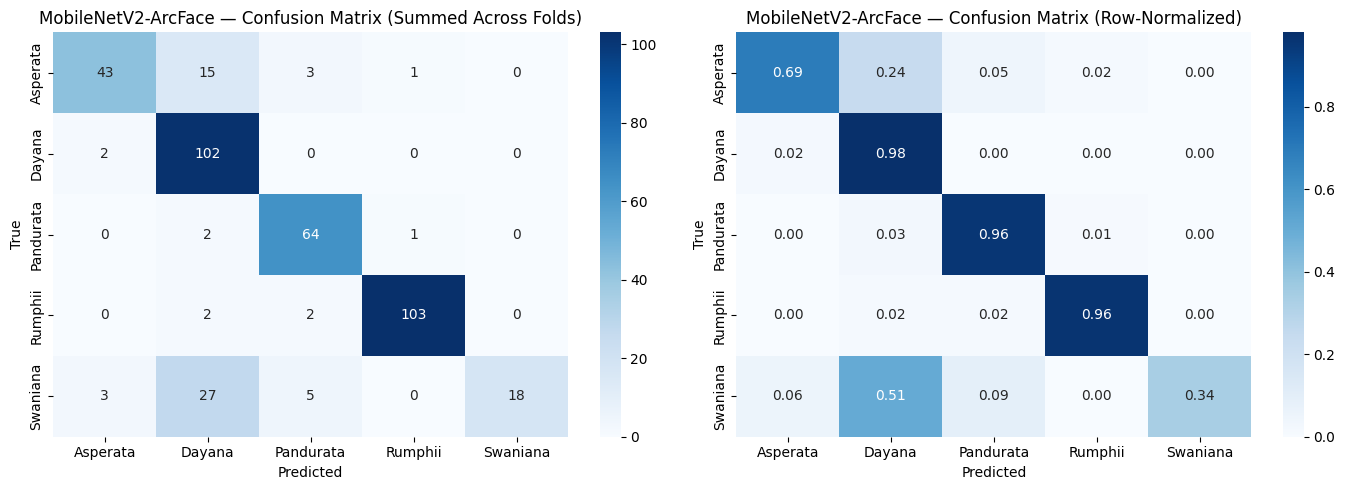

In [14]:
# =========================
# Run report 1: MobileNetV2-ArcFace
# =========================
mobilenet_cv_report = run_stratified_cv_arcface('mobilenetv2')



------------------------------------------------------------------------------------------
efficientnetv2s | Fold 1/5
------------------------------------------------------------------------------------------
Epoch 1/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 40s 337ms/step - accuracy: 0.0127 - loss: 10.7938 - val_accuracy: 0.6456 - val_loss: 1.6520 - learning_rate: 0.0010
Epoch 2/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 14s 166ms/step - accuracy: 0.1624 - loss: 7.4843 - val_accuracy: 0.7975 - val_loss: 1.2709 - learning_rate: 0.0010
Epoch 3/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 13s 162ms/step - accuracy: 0.2516 - loss: 6.8936 - val_accuracy: 0.8734 - val_loss: 0.7862 - learning_rate: 0.0010
Epoch 4/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 12s 144ms/step - accuracy: 0.2420 - loss: 7.1645 - val_accuracy: 0.8101 - val_loss: 0.7203 - learning_rate: 0.0010
Epoch 5/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 14s 169ms/step - accuracy: 0.3153 - loss: 6.1488 - val_accuracy: 0.7975 - val_loss: 0.8517 - learning_rate: 0.0010
Epoch 6/15
79/79 ━━━━━━━

,fold,accuracy,loss,n_train,n_val
0,1,0.936709,0.265069,314,79
1,2,0.987342,0.116818,314,79
2,3,0.974684,0.221618,314,79
3,4,1.000000,0.079034,315,78
4,5,0.987179,0.177469,315,78


Aggregate accuracy: mean=0.9772, std=0.0243, 95% CI=±0.0213

Per-class precision/recall/F1 (mean ± std):


,class,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std
0,Asperata,0.984615,0.034401,0.951282,0.044550,0.967224,0.032888
1,Dayana,0.971818,0.025793,0.980952,0.042592,0.976064,0.029878
2,Pandurata,0.973333,0.036515,0.984615,0.034401,0.978207,0.020021
3,Rumphii,0.990909,0.020328,0.990476,0.021296,0.990471,0.013055
4,Swaniana,0.966667,0.074536,0.963636,0.049793,0.964389,0.056877


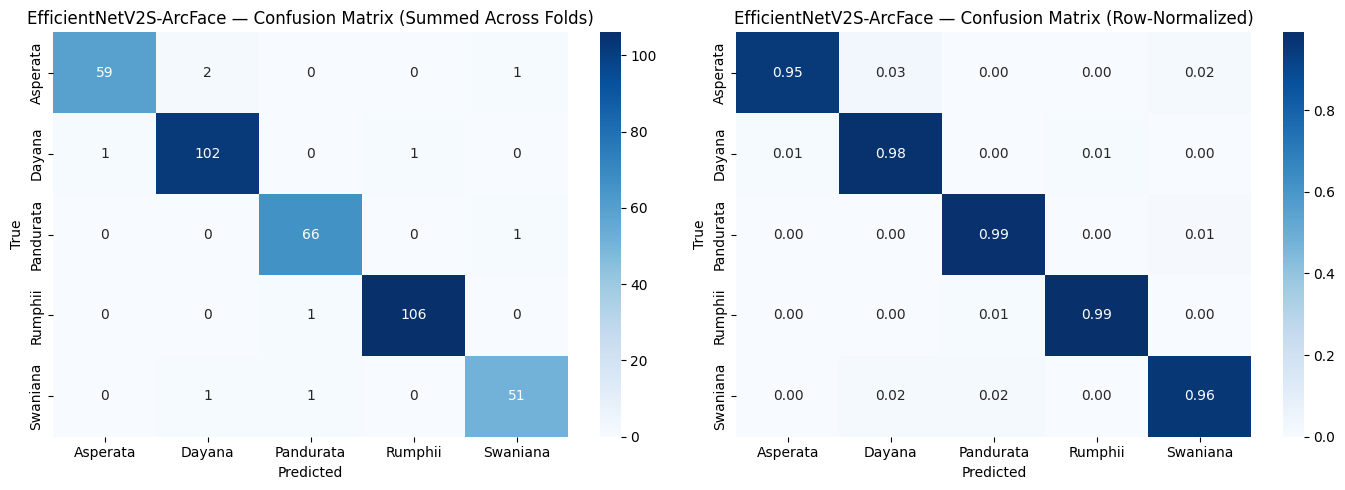

In [15]:
# =========================
# Run report 2: EfficientNetV2S-ArcFace
# =========================
efficientnet_cv_report = run_stratified_cv_arcface('efficientnetv2s')


## Follow-up (explicitly out of scope)

Collecting additional specimens/sessions per species for a true held-out species-generalization test is **not solved in this notebook**.
That is a **data collection task** and should be scheduled separately before any model accuracy is reported externally as species-generalization performance.
